# Use this Notebook to load and test report tasks

In [3]:
import dateutil.tz
from time import perf_counter
import dateutil.tz

import pandas as pd
from influxdb_client import InfluxDBClient
import matplotlib.pyplot as plt

import os
from dotenv import load_dotenv

Load the correct .env file for your source data

Required variables:
* INFLUX_HOST
* INFLUX_ORG
* INFLUX_DBNAME
* INFLUX_TOKEN
* INFLUX_MEAS

In [4]:
load_dotenv('doanna.env')

influx_host = os.getenv('INFLUX_HOST')
influx_org = os.getenv('INFLUX_ORG')
influx_dbname = os.getenv('INFLUX_DBNAME')
influx_token = os.getenv('INFLUX_TOKEN')
influx_meas = os.getenv('INFLUX_MEAS')

## Set Start and End Marks

The following cell is used for start and stop time using the "TimeMark" format: YYYYMMDDTHHMM
Note that these are zulu times in Minutes resolution.

* YYYYMMDDTHHMM

  * YYYY - 4-digit Year
  *  MM - 2-digit Month
  * DD - 2-digit Day
  * T - time follows in Zulu (UTC) time
  * HH - 2-digit hour - 24 hour clock
  * MM - 2-digit minute

In [5]:
start_mark = "20240422T0000"
end_mark = "20240423T0000"

## Prepare the query

Using provided parameters, this cell prepares the query info a string variable.

In [6]:
influx_url = f"https://{influx_host}"
zulu_tz = dateutil.tz.gettz('UTC')
start_zulu = dateutil.parser.parse(start_mark).replace(tzinfo=zulu_tz)
start_string = start_zulu.strftime("%Y-%m-%dT%H:%M:%SZ")
end_zulu = dateutil.parser.parse(end_mark).replace(tzinfo=zulu_tz)
end_string = end_zulu.strftime("%Y-%m-%dT%H:%M:%SZ")

influx_query = f'''
    from(bucket: "{influx_dbname}")
        |> range(start: {start_string}, stop: {end_string})
        |> filter(fn:(r) => r._measurement == "{influx_meas}")
        |> drop(fn: (column) => column =~ /^_(start|stop|measurement)/)
        |> pivot(rowKey:["dev_eui","_time"], columnKey: ["_field"], valueColumn: "_value")
        |> keep(columns: ["_time","dev_eui","gateway","gateway_eui",
                "rx_time","rcv_time",
                "device_addr","counter_up",
                "duplicate","frame_size","payload_size",
                "bandwidth","datarate","payload_size",
                "spreading_factor","rssi","snr","frequency","gw_latitude","gw_longitude",
                "tag1","tag2","pluscode"])
'''


## Time for the Query

Using `perf_counter`, make the query to influxDB and report the query time.

In [8]:
start_timer = perf_counter()
with InfluxDBClient(
                    url=influx_url,
                    token=influx_token,
                    org=influx_org,
                    timeout=(5000, 60000)
                    ) as client:
    try:
        influx_results = client.query_api().query_data_frame(org=influx_org, query=influx_query)
    except Exception as e:
        report_status = F'Failed: {e}'
        print(report_status)
stop_timer = perf_counter()
query_time = round(stop_timer - start_timer, 1)

print(query_time)

1.2


## Clean the Data results

First look for a list of dataframes and process into a single dataframe if needed.

Next start dropping and renaming columns as needed.

Data cleaning and normalization.

In [10]:
# this normalizes the list into a DF by adding missing columns and appending
if type(influx_results) is list:
    append_flag = False
    df_list = influx_results
    columns_set = set([col for df in df_list for col in df.columns])
    frames_df = pd.DataFrame()
    for pdf in df_list:
        missing_cols = columns_set - set(pdf.columns)
        pdf = pdf.reindex(columns=pdf.columns.tolist() + list(missing_cols))
        if append_flag:
            frames_df = pd.concat([frames_df, pdf], axis=0)
        else:
            frames_df = pdf
            append_flag = True
    influx_pdf = frames_df.reset_index(drop=True)
else:
    influx_pdf = influx_results.copy()

if influx_pdf.shape[0] == 0:
    report_status = "Empty"
    print("no results")

influx_pdf = influx_pdf.drop(columns=['result', 'table'])

# fix a few inconsistent column names
if 'rx_time' not in influx_pdf.columns and 'rcv_time' in influx_pdf.columns:
    influx_pdf = influx_pdf.rename(columns={'rcv_time': 'rx_time'})
if 'gateway' not in influx_pdf.columns and 'gateway_eui' in influx_pdf.columns:
    influx_pdf = influx_pdf.rename(columns={'gateway_eui': 'gateway'})
if 'device_addr' not in influx_pdf.columns:
    influx_pdf['device_addr'] = 'not'

# print(influx_pdf.info())

### More Data Cleaning

Setup columns as correct types.

Change some columns to categories.

In [11]:
# make a copy again for column typing
pdf = influx_pdf.copy().sort_values(by=['dev_eui', '_time']).reset_index(drop=True)

# Setup Data Types in dataframe
pdf = pdf.astype({
    'counter_up': 'Int64',
    'rx_time': 'string',
    'bandwidth': 'Int64',
    'spreading_factor': 'Int64',
    'rssi': 'Int64',
    'frequency': 'string',
})
# set Data Types only if the column exists
if 'datarate' in pdf.columns:
    pdf = pdf.astype({'datarate': 'Int64'})
if 'frame_size' in pdf.columns:
    pdf = pdf.astype({'frame_size': 'Int64'})
if 'payload_size' in pdf.columns:
    pdf = pdf.astype({'payload_size': 'Int64'})
#
if 'tag1' in pdf.columns:
    pdf = pdf.astype({'tag1': 'string'})
if 'tag2' in pdf.columns:
    pdf = pdf.astype({'tag2': 'string'})

# change low cardinality to category for memory savings
pdf = pdf.astype({
    'frequency': 'category',
    'bandwidth': 'category',
    'gateway': 'category',
    'spreading_factor': 'category',
})
if 'datarate' in pdf.columns:
    pdf = pdf.astype({'datarate': 'category'})

## Gateway Tables

Start a new frames_df copy and work on gateway tables.

First the gw_info_df, then gw_freqs_df


In [14]:
# new copy now called "frames_df" to align with django code
frames_df = pdf.copy()
# is gateway location provided (talking to you ran-bridge)
if 'gw_latitude' in frames_df.columns and 'gw_longitude' in frames_df.columns:
    gw_info_df = frames_df[['gateway', 'gw_latitude', 'gw_longitude']] \
        .drop_duplicates() \
        .dropna() \
        .reset_index(drop=True)
    # only one location per gateway in case of GPS change
    gw_info_df = gw_info_df.drop_duplicates(subset=['gateway'])
    gw_info_df = gw_info_df.rename(columns={'gw_latitude': 'lat', 'gw_longitude': 'long'})
else:
    # create a blank dataframe for return - No Locations for Gateways!
    gw_info_df = pd.DataFrame()

gw_info_df = gw_info_df.set_index('gateway')

# # count frames per gateway in frames_df
# gateway_frame_counts = frames_df['gateway'].value_counts()
# gateway_frame_counts.columns = ['gateway', 'frame_count']
gw_framecount_df = frames_df.groupby(['gateway'],
                                     observed=False).size().to_frame("frames")

gw_info_df = gw_info_df.join(gw_framecount_df)

gw_freqs_df = frames_df.groupby(['gateway', 'frequency'],
                                observed=False).size().to_frame("frames")
gw_freqs_df = gw_freqs_df.reset_index().pivot(index='gateway', columns='frequency', values='frames')

gw_freqs_df = gw_freqs_df.join(gw_framecount_df)

count_col = gw_freqs_df.pop('frames')
gw_freqs_df.insert(0, 'frames', count_col)
gw_freqs_df = gw_freqs_df.sort_values('frames', ascending=False)

## Create a graph of frequency totals

Use a panda sum() and cerate the plot.

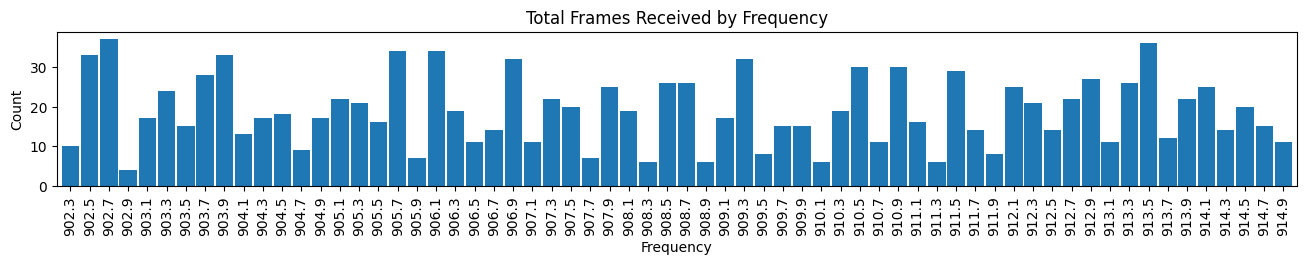

In [15]:
# gw_freqs_df = gw_freqs_df.drop('frames', axis=1)
total_freqs = gw_freqs_df.drop('frames', axis=1).sum()

plt.figure(figsize=(16, 2))
total_freqs.plot.bar(width=0.9)
plt.title("Total Frames Received by Frequency")
plt.xlabel("Frequency")
plt.ylabel("Count")
plt.show()


## Now create graphs for all gateways

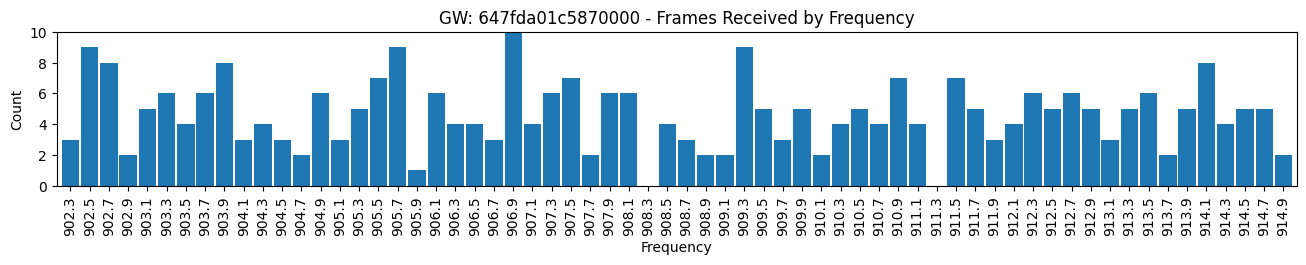

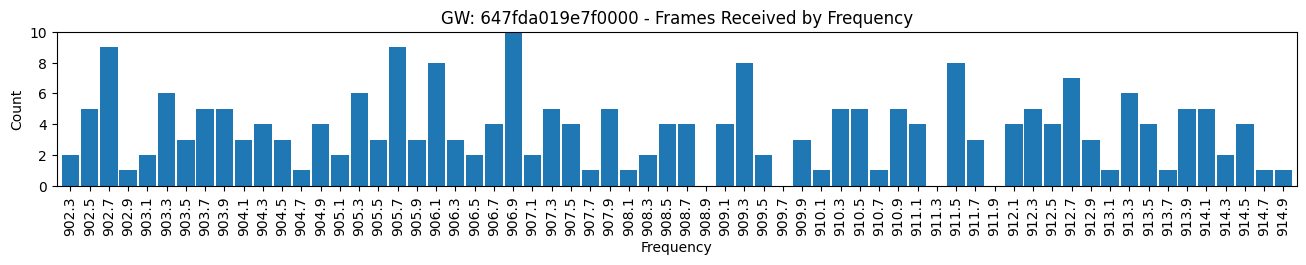

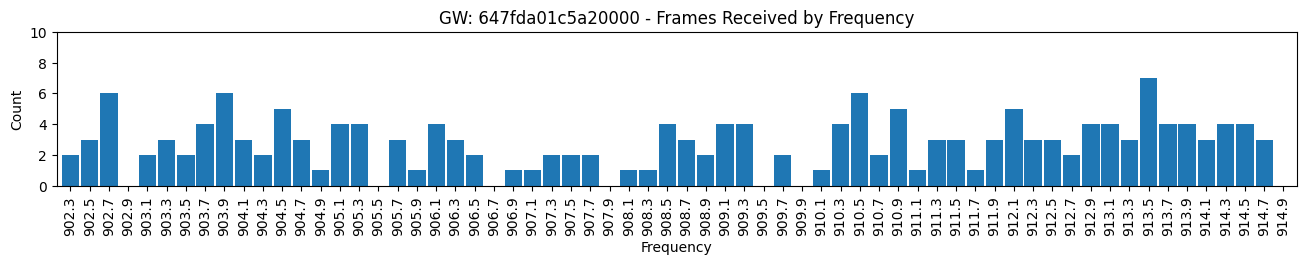

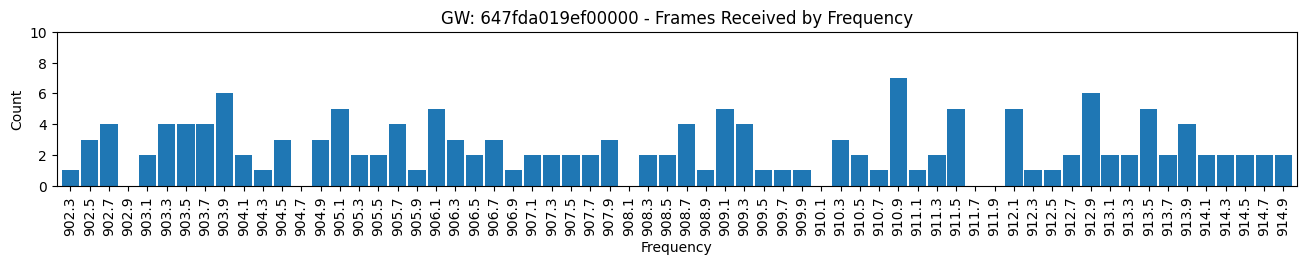

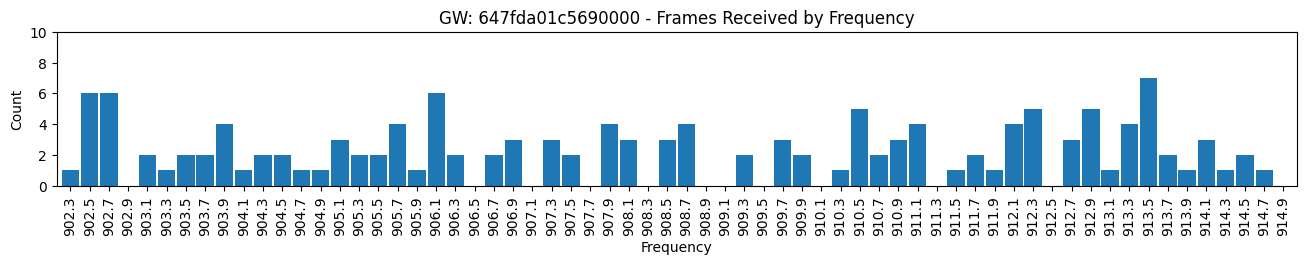

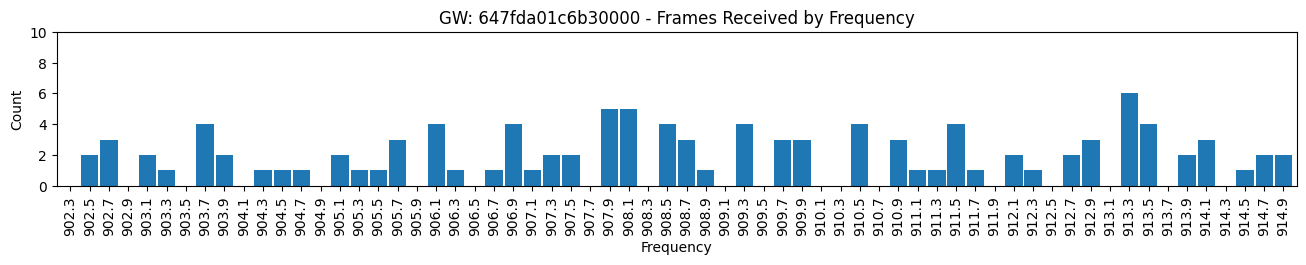

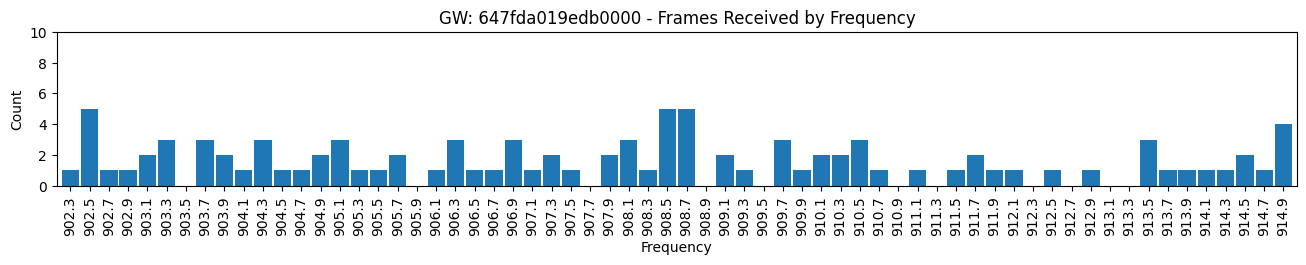

In [16]:
max_count = gw_freqs_df.drop('frames',axis=1).max().max()
# Create a bar chart for each gateway in gw_freqs_df

for gateway in gw_freqs_df.index:
    plt.figure(figsize=(16, 2))
    freqs = gw_freqs_df.loc[gateway].drop('frames')
    freqs.plot.bar(width=0.9)
    plt.title(f"GW: {gateway} - Frames Received by Frequency")
    plt.xlabel("Frequency")
    plt.ylabel("Count")
    plt.ylim(0, max_count)
    plt.show()
